# Mortalidad respiratoria/cardiovascular y rezago (lag) en la Ciudad de México

**Pregunta principal:** ¿Qué combinaciones de condiciones meteorológicas y niveles de contaminantes en la Ciudad de México, con qué rezago temporal (lag) respecto al evento, están más asociadas con incrementos en la mortalidad diaria por causas respiratorias y cardiovasculares, y qué patrones podrían usarse como señal temprana de días de mayor riesgo?

Este notebook es la primera evidencia de esta nueva etapa del proyecto (ver `docs/project_scope.md` y `docs/decisions.md`). Consume el panel diario ya construido y aplica el análisis exploratorio de correlación cruzada por rezago.

**Prerrequisitos** (ejecutar antes, desde la raíz del repositorio):

```bash
python -m src.processing.procesar_mortalidad_inegi data/raw/defunciones_2023.dbf data/raw/defunciones_2024.dbf
python -m src.processing.construir_panel_cdmx
python -m src.analysis.analisis_rezago
```

Este notebook asume que `data/CDMX_panel_diario.csv` ya existe. Las celdas de código son ejecutables, pero como el proyecto todavía no tiene los microdatos de mortalidad de INEGI descargados, no traen salidas precalculadas: se completan al correr el pipeline con datos reales.

## 1. Cargar el panel diario

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Permite importar los modulos de src/ (este notebook vive en notebooks/,
# un nivel por debajo de la raiz del repositorio).
sys.path.append(str(Path.cwd().parent))

from src.analysis.analisis_rezago import (
    DESENLACES,
    VARIABLES_BASE,
    calcular_correlaciones_por_rezago,
    mejor_rezago_por_variable,
)

RUTA_PANEL = "../data/CDMX_panel_diario.csv"

panel = pd.read_csv(RUTA_PANEL, parse_dates=["fecha"])
panel.head()

,country,city,latitude,longitude,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,...,ozone_lag5,ozone_lag6,ozone_lag7,ozone_lag8,ozone_lag9,ozone_lag10,ozone_lag11,ozone_lag12,ozone_lag13,ozone_lag14
0,Mexico,Mexico City,19.4326,-99.1332,22.124000,8.324,14.388583,20.143650,6.912703,12.770397,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Mexico,Mexico City,19.4326,-99.1332,21.774000,7.024,13.767750,19.319086,4.806564,11.733098,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mexico,Mexico City,19.4326,-99.1332,26.074001,9.074,17.334417,23.728310,7.420865,15.283680,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Mexico,Mexico City,19.4326,-99.1332,26.674002,9.124,16.707335,25.341770,7.453607,15.007007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Mexico,Mexico City,19.4326,-99.1332,30.424002,14.074,22.394835,29.516685,13.381374,20.780313,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Diagnóstico inicial del panel

In [8]:
print("Dimensiones:", panel.shape)
print("Rango de fechas:", panel["fecha"].min(), "a", panel["fecha"].max())
print("\nDuplicados por fecha:", panel.duplicated(subset=["fecha"]).sum())
print("\nValores faltantes en variables clave:")
panel[VARIABLES_BASE + DESENLACES].isna().sum()

Dimensiones: (136, 174)
Rango de fechas: 2023-01-05 00:00:00 a 2024-04-20 00:00:00

Duplicados por fecha: 0

Valores faltantes en variables clave:


temperature_2m_mean          0
apparent_temperature_mean    0
precipitation_sum            0
wind_speed_10m_max           0
pm10                         0
pm2_5                        0
carbon_monoxide              0
nitrogen_dioxide             0
sulphur_dioxide              0
ozone                        0
respiratoria                 0
cardiovascular               0
defunciones_totales          0
dtype: int64

In [9]:
panel[DESENLACES].describe()

,respiratoria,cardiovascular,defunciones_totales
count,136.000000,136.000000,136.000000
mean,24.073529,54.588235,193.801471
std,12.857989,26.590578,91.611727
min,0.000000,0.000000,1.000000
25%,20.000000,53.000000,205.750000
50%,27.000000,63.000000,226.500000
75%,33.000000,71.000000,244.250000
max,50.000000,95.000000,305.000000


## 3. Correlación cruzada (CCF) por rezago

Para cada variable de exposición (clima y contaminantes) y cada desenlace de mortalidad, se calcula la correlación de Spearman entre la variable rezagada 0 a 14 días y el conteo de defunciones del día.

In [10]:
tabla_correlaciones = calcular_correlaciones_por_rezago(panel)
tabla_correlaciones.head()

,variable,rezago_dias,desenlace,correlacion_spearman,n_observaciones
0,temperature_2m_mean,0,respiratoria,-0.074984,136
1,temperature_2m_mean,0,cardiovascular,-0.142041,136
2,temperature_2m_mean,0,defunciones_totales,-0.118643,136
3,temperature_2m_mean,1,respiratoria,-0.132672,135
4,temperature_2m_mean,1,cardiovascular,-0.171059,135


In [11]:
resumen = mejor_rezago_por_variable(tabla_correlaciones)
resumen

,variable,rezago_dias,desenlace,correlacion_spearman,n_observaciones
0,sulphur_dioxide,9,defunciones_totales,0.319569,127
1,sulphur_dioxide,9,respiratoria,0.281705,127
2,sulphur_dioxide,10,cardiovascular,0.281321,126
3,nitrogen_dioxide,9,defunciones_totales,0.254599,127
4,nitrogen_dioxide,10,cardiovascular,0.252842,126
5,nitrogen_dioxide,13,respiratoria,0.241452,123
6,carbon_monoxide,1,defunciones_totales,0.161778,135
7,carbon_monoxide,5,respiratoria,0.126691,131
8,carbon_monoxide,10,cardiovascular,0.105546,126
9,pm2_5,5,cardiovascular,-0.126126,131


## 4. Mapa de calor: correlación por variable y rezago

Un mapa de calor por desenlace ayuda a ver, de un vistazo, en qué rezago se concentra la asociación de cada variable (candidatos a señal temprana).

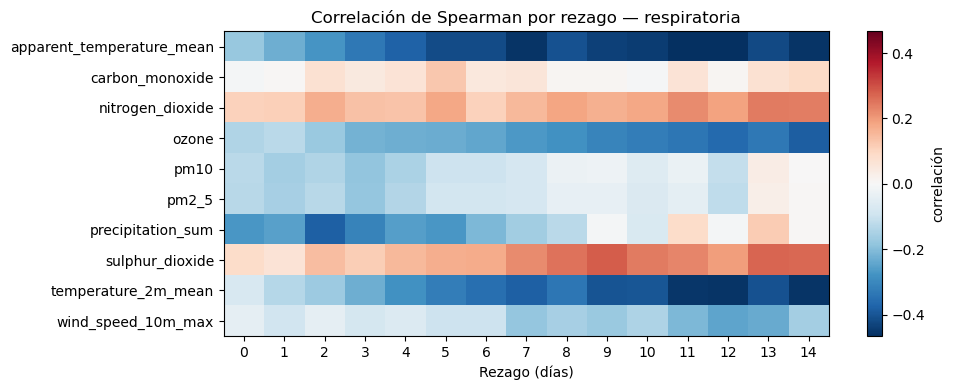

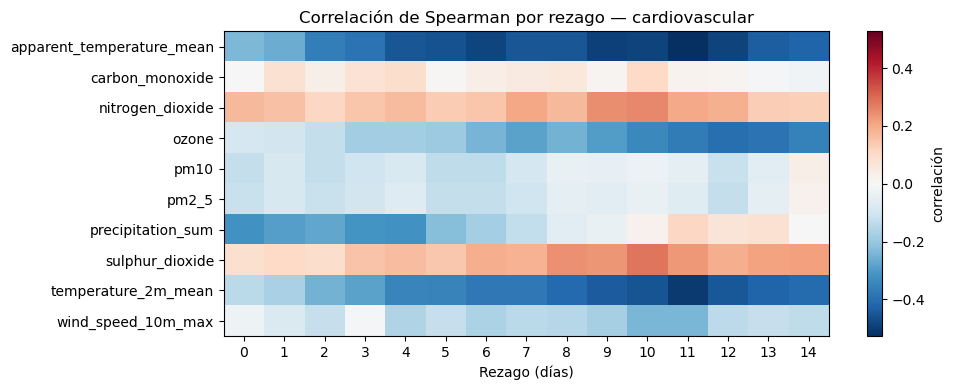

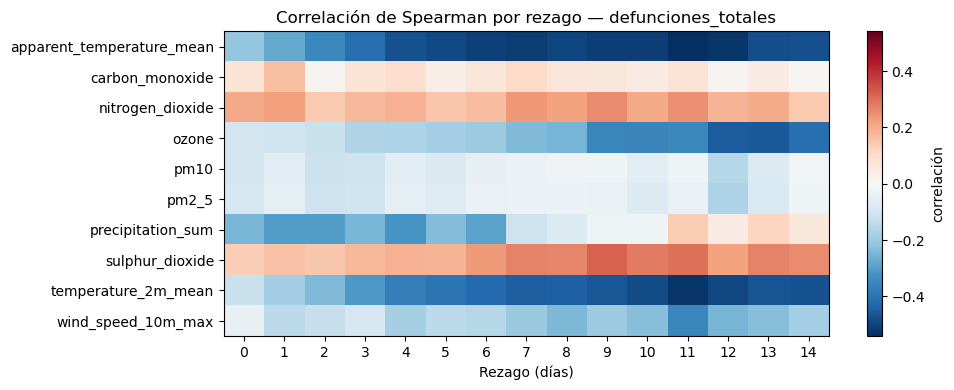

In [12]:
def graficar_mapa_calor(tabla_correlaciones, desenlace):
    pivote = tabla_correlaciones[tabla_correlaciones["desenlace"] == desenlace].pivot(
        index="variable", columns="rezago_dias", values="correlacion_spearman"
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    limite = np.nanmax(np.abs(pivote.values)) if pivote.size else 1
    imagen = ax.imshow(pivote.values, cmap="RdBu_r", vmin=-limite, vmax=limite, aspect="auto")

    ax.set_xticks(range(len(pivote.columns)))
    ax.set_xticklabels(pivote.columns)
    ax.set_yticks(range(len(pivote.index)))
    ax.set_yticklabels(pivote.index)
    ax.set_xlabel("Rezago (días)")
    ax.set_title(f"Correlación de Spearman por rezago — {desenlace}")
    fig.colorbar(imagen, ax=ax, label="correlación")
    fig.tight_layout()
    return fig


for desenlace in DESENLACES:
    graficar_mapa_calor(tabla_correlaciones, desenlace)
    plt.show()

## 5. Interpretación (primera evidencia)

Con los datos de 2024 disponibles (136 días, concentrados entre enero y abril),
las señales más claras son:

1. **Temperatura** (`temperature_2m_mean`, `apparent_temperature_mean`): correlación
   negativa en los tres desenlaces, que se fortalece con el rezago (más intensa
   entre 10 y 14 días). Los días más fríos se asocian con más muertes respiratorias
   y cardiovasculares una o dos semanas después.
2. **Dióxido de azufre** (`sulphur_dioxide`): correlación positiva que se vuelve más
   fuerte con el rezago, con su punto máximo alrededor de 7 a 11 días. Es la señal
   de contaminante más clara del conjunto: niveles más altos de SO2 preceden
   incrementos en mortalidad con más de una semana de anticipación.
3. **Dióxido de nitrógeno** (`nitrogen_dioxide`): correlación positiva moderada,
   relativamente estable en todos los rezagos.
4. **PM10 y PM2.5**: correlación casi nula en este periodo; no se detecta una
   asociación clara, a diferencia de lo reportado en la literatura.
5. **Precipitación**: correlación negativa en rezagos cortos (0 a 4 días), que se
   debilita en rezagos más largos.

**Limitación:** con solo 136 días, concentrados en su mayoría en enero-abril, la
correlación con temperatura y ozono puede estar confundida con el patrón estacional
(la mortalidad respiratoria y cardiovascular ya es naturalmente más alta en meses
fríos, independientemente de la contaminación). Separar el efecto estacional del
efecto real de cada contaminante requiere un modelo de regresión que controle por
tendencia y estación del año (ver sección de Próximos pasos), y se beneficiaría de
incorporar también los datos de mortalidad de 2023 para cubrir un ciclo estacional
completo.
